<a href="https://colab.research.google.com/github/waelydz/ASD-Sense/blob/main/Model_VGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib
!pip install kagglehub
!pip install scikit-learn seaborn

  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 13.9 MB/s  0:00:00
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]


In [ ]:
import os
os.environ['XLA_FLAGS'] = '--xla_gpu_autotune_level=0'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Success! TensorFlow found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(gpu)
else:
    print("Warning: No GPU detected. TensorFlow is using the CPU.")

I0000 00:00:1776721074.523874   30794 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Success! TensorFlow found 1 GPU(s):
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


W0000 00:00:1776721077.627683   30794 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [ ]:
import os
import shutil
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub

DATASET_DIR = kagglehub.dataset_download('imranliaqat32/autism-spectrum-disorder-in-childrenhandgestures')
BINARY_DIR = os.path.join(DATASET_DIR, "binary_format_v2")

if not os.path.exists(BINARY_DIR):
    os.makedirs(os.path.join(BINARY_DIR, "yes_ASD"), exist_ok=True)
    os.makedirs(os.path.join(BINARY_DIR, "no_ASD"), exist_ok=True)

    for root, dirs, files in os.walk(DATASET_DIR):
        if "binary_format" in root:
            continue

        for file_name in files:
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                src_path = os.path.join(root, file_name)
                if "Non-ASD" in root:
                    shutil.copy(src_path, os.path.join(BINARY_DIR, "no_ASD", file_name))
                elif "ASD" in root:
                    shutil.copy(src_path, os.path.join(BINARY_DIR, "yes_ASD", file_name))

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    BINARY_DIR,
    label_mode='binary',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    BINARY_DIR,
    label_mode='binary',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 1708 files belonging to 2 classes.
Using 1367 files for training.


W0000 00:00:1776721078.728673   30794 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776721078.876986   30794 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13153 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0a
W0000 00:00:1776721079.328684   31080 subprocess_compilation.cc:241] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
W0000 00:00:1776721079.328712   31080 subprocess_compilation.cc:244] Used ptxas at /usr/local/cuda/bin/ptxas
W0000 00:00:1776721079.328745   31080 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721079.329844   31081 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas.

Found 1708 files belonging to 2 classes.
Using 341 files for validation.


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

def build_vgg16():
    base_model = VGG16(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze the heavy base model
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    # VGG16 specific preprocessing (converts to BGR and zero-centers)
    x = tf.keras.applications.vgg16.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

vgg_model = build_vgg16()

W0000 00:00:1776721080.090608   31150 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721080.091662   31159 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721080.093060   31149 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721080.094518   31148 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721080.095878   31157 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721080.097103   31158 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721080.098617   31160 gpu_kernel_to_blob_pass.cc:190] Failed to co

In [ ]:
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy'],
    jit_compile=False
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint("best_vgg16.keras", save_best_only=True)

print("\nStarting VGG16 Training...")
vgg_history = vgg_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[checkpoint]
)


Starting VGG16 Training...
Epoch 1/30


W0000 00:00:1776721081.141340   31224 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721081.144297   31225 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721081.147428   31218 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721081.153978   31217 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721081.159165   31230 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721081.162145   31231 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721081.172216   31224 gpu_kernel_to_blob_pass.cc:190] Failed to co

 3/43 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.2691 - loss: 2.6625

W0000 00:00:1776721085.912909   31073 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1776721085.954499   31073 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.5794 - loss: 1.1502 - val_accuracy: 0.8182 - val_loss: 0.4368
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.7922 - loss: 0.4750 - val_accuracy: 0.9179 - val_loss: 0.2578
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8435 - loss: 0.3752 - val_accuracy: 0.9472 - val_loss: 0.2116
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8873 - loss: 0.2932 - val_accuracy: 0.9501 - val_loss: 0.1874
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9078 - loss: 0.2577 - val_accuracy: 0.9472 - val_loss: 0.1742
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9049 - loss: 0.2446 - val_accuracy: 0.9443 - val_loss: 0.1589
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9166 - loss: 0.2164 - val_accuracy: 0.9531 - val_loss: 0.1500
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9225 - loss: 0.2100 - val_accuracy: 0.9648 - val_loss: 

In [ ]:
best_vgg = tf.keras.models.load_model("best_vgg16.keras")

print("\nEvaluating the Best Saved Model...")
val_loss, val_acc = best_vgg.evaluate(val_dataset)

print("-" * 30)
print(f"OFFICIAL FINAL ACCURACY: {val_acc * 100:.2f}%")
print(f"OFFICIAL FINAL LOSS:     {val_loss:.4f}")
print("-" * 30)


Evaluating the Best Saved Model...
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9707 - loss: 0.0931
------------------------------
OFFICIAL FINAL ACCURACY: 97.07%
OFFICIAL FINAL LOSS:     0.0931
------------------------------


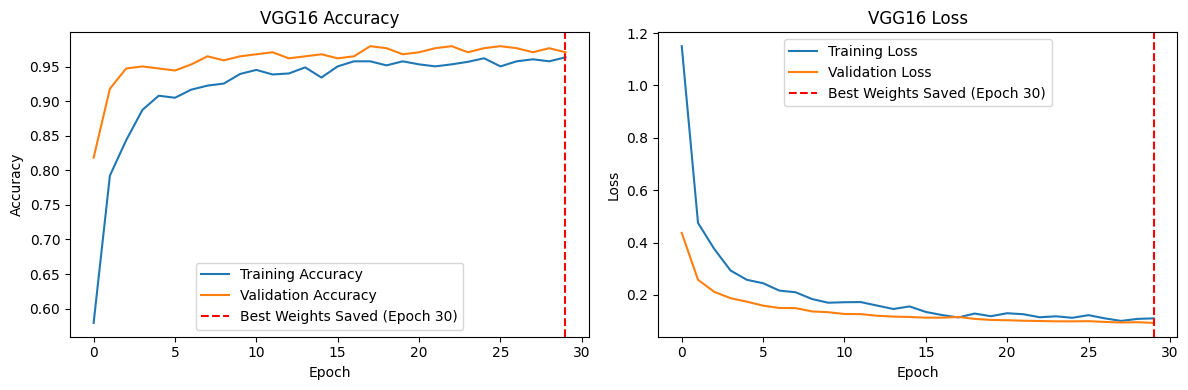

In [ ]:
best_epoch = vgg_history.history['val_loss'].index(min(vgg_history.history['val_loss']))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(vgg_history.history['accuracy'], label='Training Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Validation Accuracy')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Weights Saved (Epoch {best_epoch + 1})')
plt.title('VGG16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vgg_history.history['loss'], label='Training Loss')
plt.plot(vgg_history.history['val_loss'], label='Validation Loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Weights Saved (Epoch {best_epoch + 1})')
plt.title('VGG16 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("vgg16_training_metrics.png")
plt.show()

Analyzing VGG16...


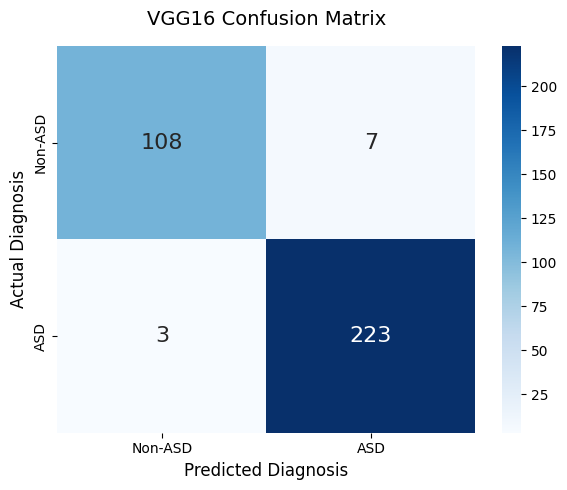


Detailed Metrics for VGG16:
              precision    recall  f1-score   support

     Non-ASD       0.97      0.94      0.96       115
         ASD       0.97      0.99      0.98       226

    accuracy                           0.97       341
   macro avg       0.97      0.96      0.97       341
weighted avg       0.97      0.97      0.97       341



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def generate_evaluation_metrics(model, dataset, model_name):
    print(f"Analyzing {model_name}...")
    y_true = []
    y_pred_probs = []

    # Iterate through the dataset to extract exact labels and predictions
    for images, labels in dataset:
        y_true.extend(labels.numpy().flatten())
        preds = model.predict_on_batch(images)
        y_pred_probs.extend(preds.flatten())

    y_true = np.array(y_true)
    # Convert probability percentages to strict 0 or 1 predictions
    y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

    # --- 1. Plot Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    # Using a clean blue color map for academic reporting
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-ASD', 'ASD'],
                yticklabels=['Non-ASD', 'ASD'],
                annot_kws={"size": 16})
    plt.title(f'{model_name} Confusion Matrix', fontsize=14, pad=15)
    plt.ylabel('Actual Diagnosis', fontsize=12)
    plt.xlabel('Predicted Diagnosis', fontsize=12)
    plt.tight_layout()

    # Automatically save a high-res copy for your Overleaf document
    file_name = f"{model_name.lower().replace(' ', '_')}_matrix.png"
    plt.savefig(file_name, dpi=300)
    plt.show()

    # --- 2. Print Classification Report ---
    print(f"\nDetailed Metrics for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=['Non-ASD', 'ASD']))

generate_evaluation_metrics(best_vgg, val_dataset, "VGG16")